# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [3]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [11]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
# display all rows - without  missing data 

mpg_data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [ ]:
#another way to explore the data [only numeric variables]
mpg_data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [16]:
mpg_data.shape[0] #number of rows

392

In [17]:
mpg_data.shape[1] #number columns 

9

_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [18]:
mpg_data["mpg"].dtype

dtype('float64')

The variable type for mpg (the response variable) is float, indicating it is a continuous numerical variable. MPG's value can be predicted using linear regression or by averaging with KNN regression. (In contrast to a categorical variable consists of distinct categories, and its values can be predicted using logistic regression or KNN classification, which relies on a majority vote).


_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [21]:
mpg_data["horsepower"].nlargest(5)

116    230.0
8      225.0
13     225.0
95     225.0
6      220.0
Name: horsepower, dtype: float64

_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [22]:
mpg_data.shape[1] -1

8

In [28]:
#another way
predictors = mpg_data.columns[1:]
len(predictors)

8

You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

In [32]:
predictors

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'name'],
      dtype='object')

In [ ]:
mpg_data["origin"].dtype

dtype('int64')

In [37]:
mpg_data["name"].dtype

dtype('O')

In [38]:
# I checked the datatype of "name" and "origin" predictors to check why they were excluded from plotting/visualiztion. Indeed the visualiztion code
# include only int and float datatypes

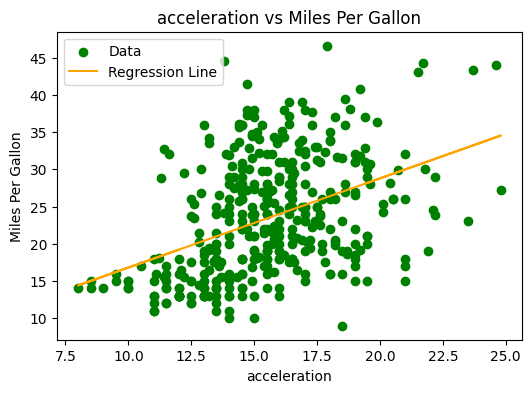

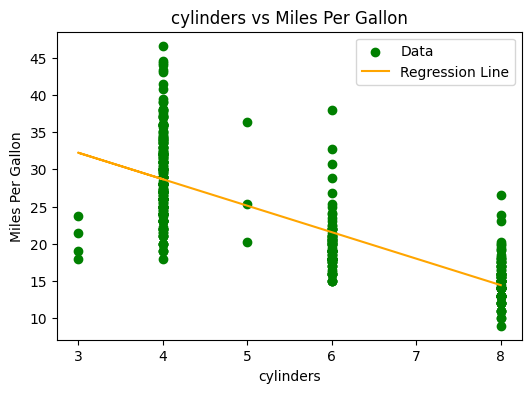

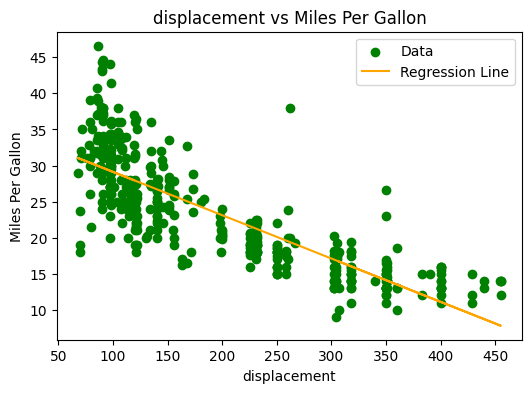

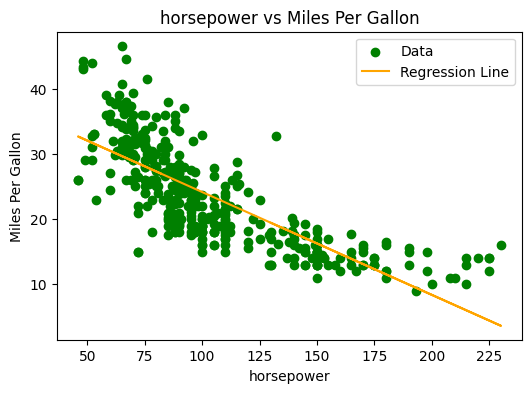

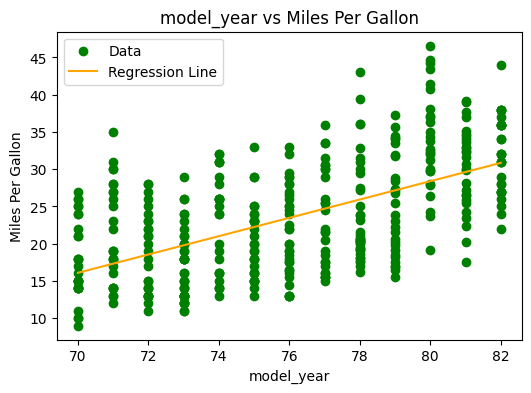

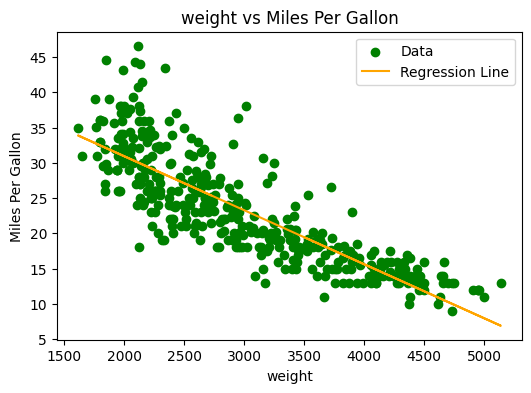

In [41]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='green')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='orange', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

weight vs mpg → negative association; model Year vs mpg → positive association; horsepowr vs mpg → negative association; displacement vs mpg → negative association; cylinders vs mpg → negative association ; accelration vs mpg → positive association

_(ii)_ What concept ‘defines’ the plotted line?

The line of best fit is plotted using the least squares method, which aims to minimize the distance between the line and the data points.

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

Not all data points fall perfectly along the line. For each plot, the line of best fit (the orange line) is determined by two parameters: β1 (slope) and β0 (intercept). Both parameters are defined using the method of least squares, which determines the values of β1 and β0 so that the line minimizes the sum of the distances from all data points. The deviations between the line of best fit and the datapoints show that the relationships between MPG and each of the predictors' plots are not perfectly linear. 


#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [82]:
mpg_data_train, mpg_data_test = train_test_split(
    mpg_data, train_size=0.75, random_state=42
)

In [76]:
#check my code 
numeric_predictors = mpg_data.select_dtypes(include=[int, float]).columns.difference(['mpg'])
numeric_predictors

Index(['acceleration', 'cylinders', 'displacement', 'horsepower', 'model_year',
       'weight'],
      dtype='object')

**Step 2: Fit the linear regression model.**

In [95]:
#my way 
#step 1: I will define, based on the visualiztion code above, only the numerical predictors
numeric_predictors = mpg_data.select_dtypes(include=[int, float]).columns.difference(['mpg'])

# step 2: I will initialize an empty model
mlm = LinearRegression()

# step 3 : I will fit the model [because we have more than ]
mlm.fit(mpg_data_train[numeric_predictors],mpg_data_train["mpg"])

# step 4 : I will create and present a dataframe with all coefficients [6 slopes + intercept]

coefficients_df = pd.DataFrame({
    "predictor": numeric_predictors,
    "slope": mlm.coef_,
    "intercept": [mlm.intercept_] * len(mlm.coef_) #to ensure that all arrays are in the same length
})

# Display the coefficients DataFrame
print(coefficients_df)



      predictor     slope  intercept
0  acceleration  0.057588 -15.047371
1     cylinders -0.160143 -15.047371
2  displacement  0.000373 -15.047371
3    horsepower -0.001899 -15.047371
4    model_year  0.762270 -15.047371
5        weight -0.006457 -15.047371


In [97]:
mlm.coef_

array([ 5.75878495e-02, -1.60142765e-01,  3.73447288e-04, -1.89866545e-03,
        7.62270091e-01, -6.45678716e-03])

In [98]:
lm.intercept_

np.float64(-15.047370795059372)

#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [102]:
mpg_data_test["predicted"] = mlm.predict(mpg_data_test[numeric_predictors])

# Calculate RMSPE 
lm_mult_test_RMSPE = mean_squared_error(
    y_true=mpg_data_test["mpg"],
    y_pred=mpg_data_test["predicted"]
)**(0.5)

lm_mult_test_RMSPE

3.1854749513391494

Interpretation: This result indicates that, on average, our model deviated from the actual results by 3.185 units (on average per observation).In other words, our model, on average, predicted miles per gallon (mpg) with an error of 3.185 mpg [when accounting for/predicting based on all six numerical predictors].

In [105]:
# Calculate r2 
from sklearn.metrics import r2_score
lm_mult_test_r2 = r2_score ( 
    y_true=mpg_data_test["mpg"], 
    y_pred=mpg_data_test["predicted"] 
)

lm_mult_test_r2

0.7987978489938286

Interpretation: This result shows that our model, which includes six numerical predictors, accounts for/explains 79.87% of the variance in the outcome variable (mpg, miles per gallon)

In [106]:
#with cross vaidation, C=10
from sklearn.model_selection import cross_validate
returned_dictionary_mlm = cross_validate(
    estimator=mlm, 
    cv=5,    
    X=mpg_data[numeric_predictors],
    y=mpg_data["mpg"],
    scoring="neg_root_mean_squared_error" 
)

cv_5_df_mlm = pd.DataFrame(returned_dictionary_mlm)   
cv_5_df_mlm["test_score"] = cv_5_df_mlm["test_score"].abs()

cv_5_df_mlm

,fit_time,score_time,test_score
0,0.105826,0.028030,3.951074
1,0.002004,0.002086,3.377467
2,0.002913,0.002999,2.511393
3,0.002012,0.001000,3.909300
4,0.001986,0.001000,5.546094


In [107]:
cv_5_metrics_mlm = cv_5_df_mlm.agg(["mean","sem"])
cv_5_metrics_mlm

,fit_time,score_time,test_score
mean,0.022948,0.007023,3.859065
sem,0.020720,0.005265,0.495238


When I used cross-validation, the mean RSMPE across five validations was 3.85, with a SEM of 0.4, indicating a larger error in predicting mpg values than with the 0.75 train-test split.

In [108]:
returned_dictionary_mlm = cross_validate(
    estimator=mlm, 
    cv=5,    
    X=mpg_data[numeric_predictors],
    y=mpg_data["mpg"],
    scoring="r2" 
)

cv_5_df_mlm = pd.DataFrame(returned_dictionary_mlm)  

cv_5_df_mlm

,fit_time,score_time,test_score
0,0.072625,0.013001,0.538080
1,0.002006,0.002000,0.675233
2,0.002983,0.001998,0.812758
3,0.004356,0.003036,0.685770
4,0.002168,0.001352,0.143949


In [109]:
cv_5_metrics_mlm = cv_5_df_mlm.agg(["mean","sem"])
cv_5_metrics_mlm

,fit_time,score_time,test_score
mean,0.016828,0.004278,0.571158
sem,0.013956,0.002198,0.115313


As expected, When I used cross-validation, the mean r2 across five validations was 0.5711, with a SEM of 0.115, indicating that the model explains less variation in the response variable (mpg) than with the 0.75 train-test split [57.11% +- 11.53% versus 79.87%]

# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 12/03/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc2-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
